# Walmart Weekly Sales — Linear Regression from Scratch

**Dataset:** Walmart Stores Sales Forecasting · **Method:** Linear Regression (NumPy only, no sklearn for training) · **Difficulty:** ⭐⭐⭐ · **Estimated time:** 6–8 hours

> **Rules.** Fill every `# YOUR CODE` cell. Answer every **Question** in a new markdown cell below it (2–5 sentences, not yes/no). Before submitting: `Kernel → Restart & Run All` — the notebook must run top-to-bottom without errors. Learning from external sources is encouraged; copy-pasting solutions is not.

## About this project

You will predict **Weekly_Sales** of 45 Walmart stores using only NumPy. The dataset has time-series structure (weekly observations), mixed feature scales, a holiday flag, and macroeconomic indicators. You will engineer features from dates, handle the store ID as a category, split by time (not randomly!), and build gradient descent from scratch.

**What you will learn:** feature engineering from dates · one-hot encoding by hand · time-based train/test split · feature scaling (why and how) · gradient descent loop · Normal Equation · evaluation metrics from formulas · residual analysis · comparison with sklearn.

## Dataset: Walmart Store Sales

6435 rows × 8 columns. 45 stores, 143 weeks (Feb 2010 – Oct 2012). No missing values.

| Column | Meaning |
|---|---|
| `Store` | Store number (1–45) — **categorical**, not numeric |
| `Date` | Week start date (dd-mm-yyyy) |
| `Weekly_Sales` | Total weekly sales in USD — **target** |
| `Holiday_Flag` | 1 if the week contains a major US holiday, else 0 |
| `Temperature` | Average temperature (°F) for the region |
| `Fuel_Price` | Cost of fuel in the region ($/gallon) |
| `CPI` | Consumer Price Index |
| `Unemployment` | Unemployment rate (%) |

**Key traps:**
- `Store` is an ID, not a quantity. Store 30 is not "bigger" than Store 5. Must be one-hot encoded.
- `Date` cannot enter a numpy model directly. Extract Year, Month, Week.
- Data is **time series**: random train/test split leaks future information into training.

## 1. Load & first look

Import numpy, pandas, matplotlib. Load `Walmart_Sales.csv`. Print `shape`, `dtypes`, `describe()`, `isna().sum()`, `duplicated().sum()`.

**Question 1.** How many rows and columns? Any missing values or duplicates? What are the min/max of `Weekly_Sales` — does the range surprise you?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Walmart_Sales.csv')

# YOUR CODE: shape, dtypes, describe, isna, duplicated
print("Shape: ", df.shape)
print("dtypes: ", df.dtypes)
print("Null sum: ", df.isna().sum())
print(df.duplicated().sum())
df.describe()


Shape:  (6435, 8)
dtypes:  Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object
Null sum:  Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
0


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [2]:
print(df.head())
df.tail()

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667


## 2. EDA — Target distribution

Plot a histogram of `Weekly_Sales` (use 50 bins, add KDE with seaborn). Print the mean, median, skewness (`df['Weekly_Sales'].skew()`).

**Question 2.** Is the distribution symmetric or skewed? What does this imply for a model that minimizes MSE (which is sensitive to large errors)? Would a log-transform help?

Mean: 1046964.8775617715
Median: 960746.04
Skewness: 0.6683617974864524


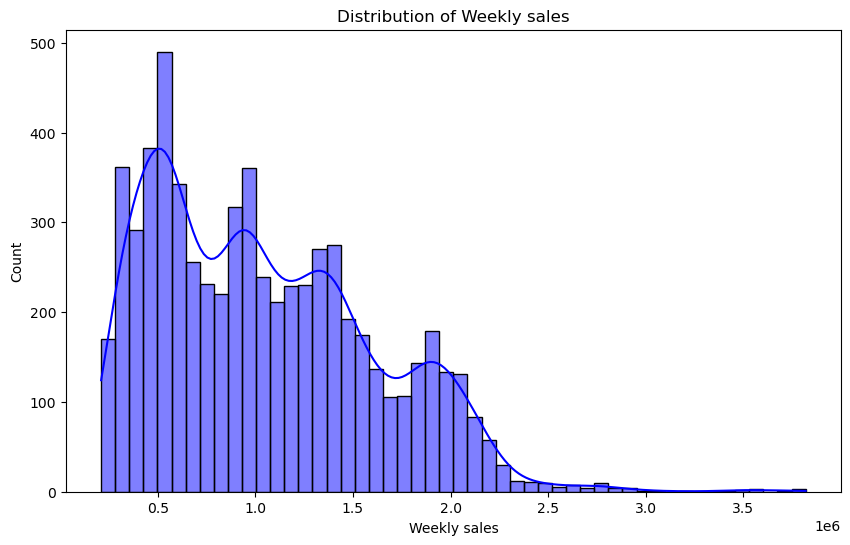

In [3]:
import seaborn as sns

# YOUR CODE: histogram of Weekly_Sales, print mean/median/skew
print("Mean:", df['Weekly_Sales'].mean())
print("Median:", df['Weekly_Sales'].median())
print("Skewness:", df['Weekly_Sales'].skew())

# histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color='blue')
plt.title("Distribution of Weekly sales")
plt.xlabel('Weekly sales')
plt.ylabel('Count')
plt.show()


## 3. EDA — Feature relationships

1. Correlation heatmap of all numeric columns (use `annot=True, cmap='coolwarm'`).
2. Scatter plot: `Temperature` vs `Weekly_Sales`.
3. Scatter plot: `Fuel_Price` vs `Weekly_Sales`.
4. Box plot: `Weekly_Sales` grouped by `Holiday_Flag` (holiday weeks vs normal weeks).
5. Bar plot: mean `Weekly_Sales` per store (which stores sell the most?).

**Question 3.** Which feature has the strongest correlation with `Weekly_Sales`? Are any features strongly correlated with each other (potential multicollinearity)? Does the holiday flag visibly affect sales?

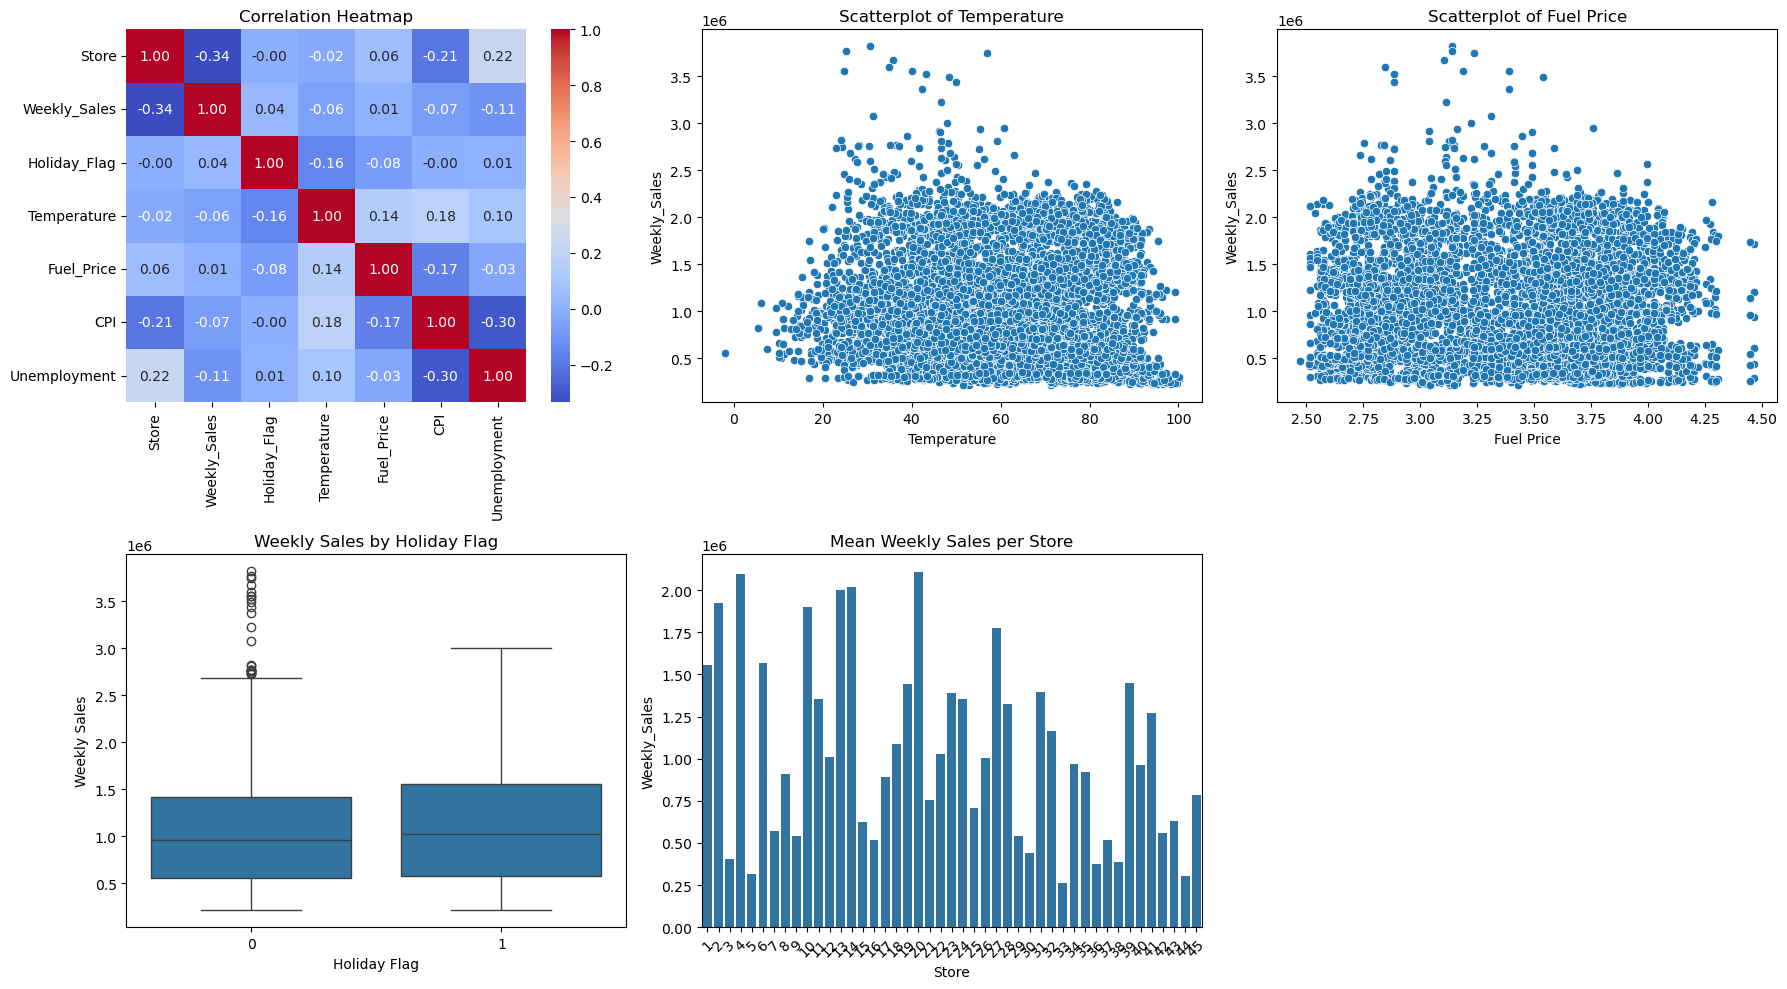

In [4]:
# YOUR CODE: heatmap, scatter plots, box plot, bar plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0][0])
axes[0][0].set_title('Correlation Heatmap')

sns.scatterplot(data=df, x='Temperature', y='Weekly_Sales', ax=axes[0][1])
axes[0][1].set_title('Scatterplot of Temperature')
axes[0][1].set_xlabel('Temperature')
axes[0][1].set_ylabel('Weekly_Sales')


sns.scatterplot(data=df, x='Fuel_Price', y='Weekly_Sales', ax=axes[0][2])
axes[0][2].set_title('Scatterplot of Fuel Price')
axes[0][2].set_xlabel('Fuel Price')
axes[0][2].set_ylabel('Weekly_Sales')

#boxplot weekly sales by holiday weeks
sns.boxplot(data=df, x="Holiday_Flag", y='Weekly_Sales', ax=axes[1][0])
axes[1][0].set_title('Weekly Sales by Holiday Flag')
axes[1][0].set_xlabel('Holiday Flag')
axes[1][0].set_ylabel('Weekly Sales')

store_sales = df.groupby('Store')['Weekly_Sales'].mean().reset_index()
sns.barplot(data=store_sales, x='Store', y='Weekly_Sales', ax=axes[1][1])
axes[1][1].set_title('Mean Weekly Sales per Store')
axes[1][1].tick_params(axis='x', rotation=45)

axes[1][2].set_visible(False)

plt.tight_layout()
plt.show()

Heatmap - negative correlation means when the values goes up in store, or in feature the 
y target decreases negatively. Like the bigger id numbered stores tend to have lesser weekly sales. than the first ones




## 4. EDA — Time patterns

Parse `Date` to datetime. Create `Year`, `Month`, `Week` columns. Then:
1. Line plot: average `Weekly_Sales` over time (group by Date, take mean across stores).
2. Bar plot: average `Weekly_Sales` by month (seasonal pattern?).
3. Line plot: one specific store's sales over time (pick store 1 or any you like).

**Question 4.** Is there a seasonal pattern? Which months have the highest sales? Can you spot the effect of holidays (Thanksgiving, Christmas) in the time series?

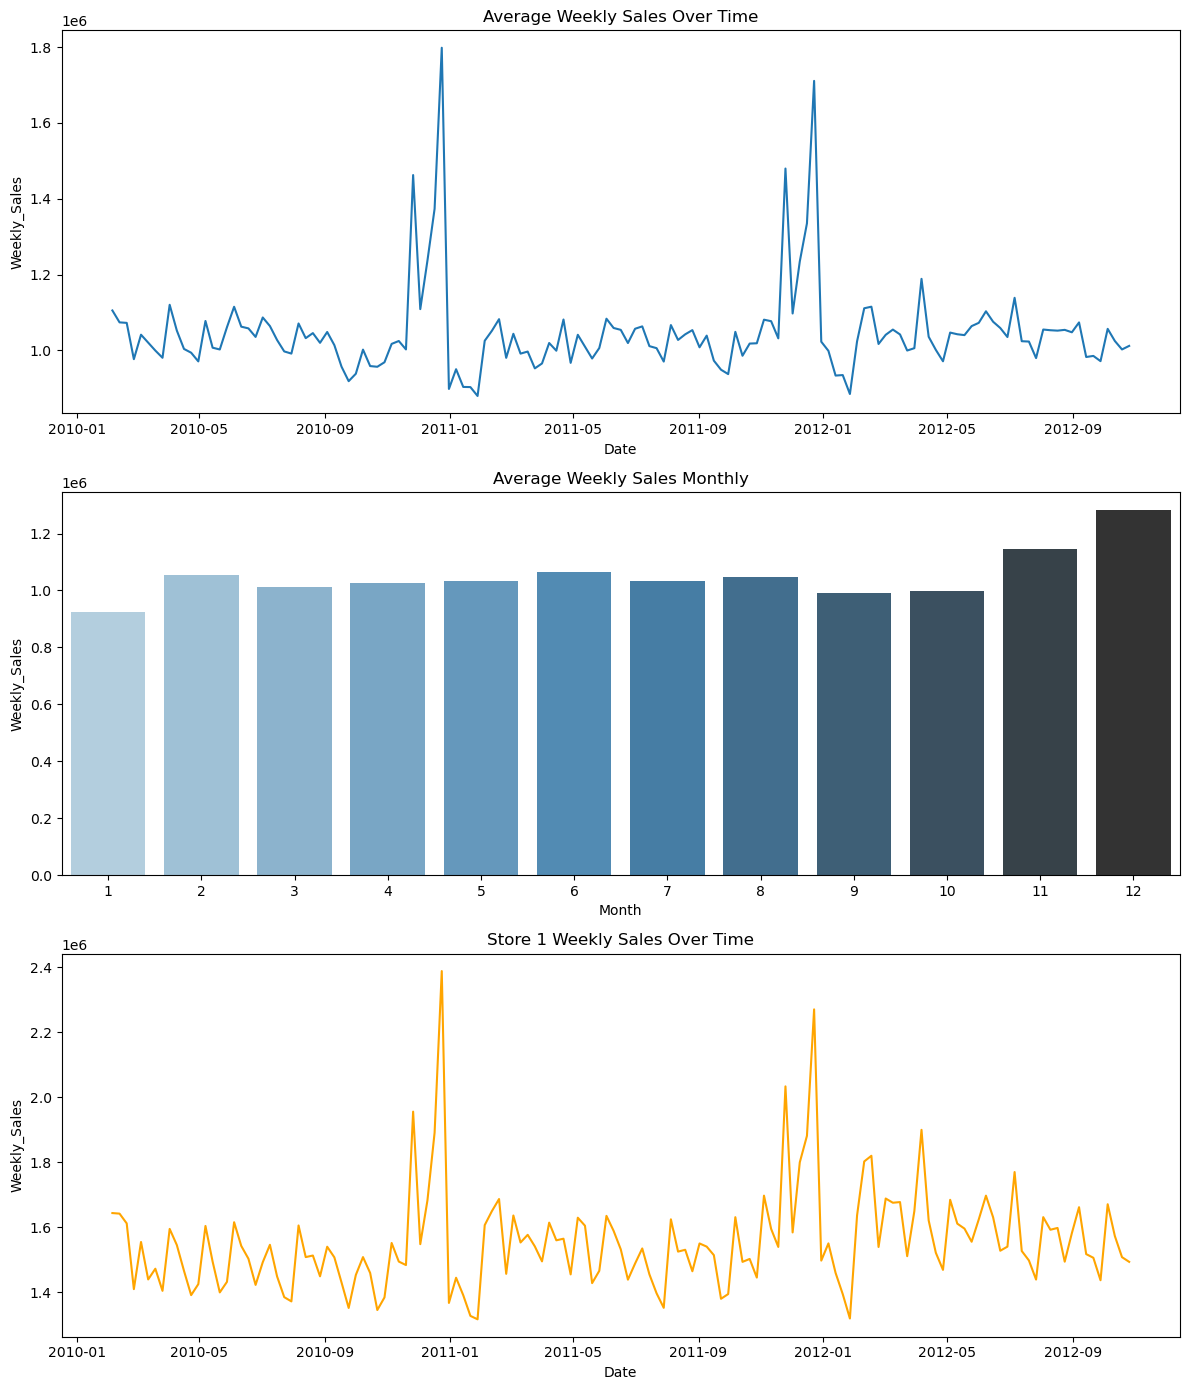

In [5]:
# YOUR CODE: parse Date, create Year/Month/Week, time plots
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# 1. Line plot: average Weekly_Sales over time
date_sales = df.groupby('Date')['Weekly_Sales'].mean().reset_index()
sns.lineplot(data=date_sales, x='Date', y='Weekly_Sales', ax=axes[0])
axes[0].set_title('Average Weekly Sales Over Time')

# 2. Bar plot: average Weekly_Sales by month
month_sales = df.groupby('Month')['Weekly_Sales'].mean().reset_index()
sns.barplot(data=month_sales, x='Month', y='Weekly_Sales', hue='Month', ax=axes[1], palette='Blues_d', legend=False)
axes[1].set_title('Average Weekly Sales Monthly')

# 3. Line plot: Store 1 weekly sales over time (Fixed filtering)
store_1 = df[df['Store'] == 1]
sns.lineplot(data=store_1, x='Date', y='Weekly_Sales', ax=axes[2], color='orange')
axes[2].set_title('Store 1 Weekly Sales Over Time')

plt.tight_layout()
plt.show()

## 5. Feature engineering

Build the final feature matrix:

1. **Drop `Date`** — the model cannot use a datetime object. You already extracted Year, Month, Week.
2. **One-hot encode `Store`** — create 45 binary columns (Store_1, Store_2, …, Store_45). Use `pd.get_dummies()` or do it by hand with numpy. Drop one column to avoid the dummy variable trap, or keep all 45 (linear regression handles it, but condition number rises).
3. **Final features:** `Holiday_Flag`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Year`, `Month`, `Week`, + 44 store dummies.
4. **Target:** `Weekly_Sales`.

Print the final `X.shape` and `y.shape`.

**Question 5.** Why can't we just put `Store` as a number 1–45 into the model? What goes wrong if the model treats store ID as numeric?

In [6]:
# YOUR CODE: build feature matrix X and target vector y

# df_encoded = pd.get_dummies(df, columns=["Store"], prefix='Store', drop_first=True, dtype=int)

X = df.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')
y = df['Weekly_Sales']

base_features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']
X = df[base_features].copy()

# one hot encode
X = pd.get_dummies(X, columns=['Store'], drop_first=True, dtype=int)
print(X.shape)
y.shape

(6435, 52)


(6435,)

## 6. Train/test split — by time, not random

This is time series. A random split lets the model see November 2012 during training and then "predict" March 2012 — that's cheating.

**How to split correctly:**
1. Sort the dataframe by `Date`.
2. Find the date at the 80th percentile of unique dates.
3. Train = all rows before that date. Test = all rows on or after.
4. Convert X and y to numpy arrays (`float64`).

Print train/test shapes, the last train date, and the first test date. Verify every store appears in both sets.

**Question 6.** Why would a random split be misleading for time series data? What kind of "information leak" happens?

In [7]:
# YOUR CODE: sort by date, find cutoff, split, convert to numpy

df_sorted = df.sort_values('Date').reset_index(drop=True)

#2 80th
unique_dates = df_sorted['Date'].unique()
cutoff_idx = int(len(unique_dates) * 0.8)
cutoff_date = unique_dates[cutoff_idx]

# splitting
train_mask = df_sorted['Date'] < cutoff_date
test_mask = df_sorted['Date'] >= cutoff_date

X_train_df = X[train_mask]
X_test_df = X[test_mask]
y_train_df = y[train_mask]
y_test_df = y[test_mask]

X_train = X_train_df.to_numpy(dtype=float)
X_test = X_test_df.to_numpy(dtype=float)
y_train = y_train_df.to_numpy(dtype=float)
y_test = y_test_df.to_numpy(dtype=float)

# Print shapes and dates to verify
print("X_train shape:", X_train.shape, "| X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape, "| y_test shape:", y_test.shape)
print("Last train date:", df_sorted[train_mask]['Date'].max().strftime('%Y-%m-%d'))
print("First test date:", df_sorted[test_mask]['Date'].min().strftime('%Y-%m-%d'))

X_train shape: (5130, 52) | X_test shape: (1305, 52)
y_train shape: (5130,) | y_test shape: (1305,)
Last train date: 2012-04-06
First test date: 2012-04-13


## 7. Feature scaling (standardization)

Gradient descent needs features on similar scales. CPI is ~200, Temperature is ~60, Holiday_Flag is 0/1, store dummies are 0/1.

1. **Compute mean and std from the training set only.**
2. Apply `(x - mean) / std` to both train and test using the **train** statistics.
3. **Do NOT scale** the one-hot (binary) columns — they're already 0/1. Only scale: `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Year`, `Month`, `Week`.

Print a few rows of the scaled X to verify the continuous features are roughly in [-2, 2] range and the binary columns are still 0/1.

**Question 7.** Why must you compute mean/std from the training set only, not the whole dataset? What happens if you use test statistics too?

In [13]:
# YOUR CODE: identify which columns to scale, compute train mean/std, apply

# Columns to scale (continuous features only — NOT binary/one-hot)
scale_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week']
scale_idx = [X_train_df.columns.get_loc(c) for c in scale_cols]

# Compute mean and std from TRAINING set onlyhey explain
train_mean = X_train[:, scale_idx].mean(axis=0)
train_std = X_train[:, scale_idx].std(axis=0)

# Apply standardization to continuous columns only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[:, scale_idx] = (X_train[:, scale_idx] - train_mean) / train_std
X_test_scaled[:, scale_idx] = (X_test[:, scale_idx] - train_mean) / train_std

# Verify: continuous features near [-2, 2], binary columns still 0/1
print("Scaled continuous (first row):", X_train_scaled[0, scale_idx].round(2))
print("Binary cols (first row, last 5):", X_train_scaled[0, -5:])
print("Train mean of scaled cols:", X_train_scaled[:, scale_idx].mean(axis=0).round(4))
print("Train std of scaled cols:", X_train_scaled[:, scale_idx].std(axis=0).round(4))

Scaled continuous (first row): [-0.97 -1.71  0.99  0.1  -1.21 -1.37 -1.47]
Binary cols (first row, last 5): [0. 0. 0. 0. 0.]
Train mean of scaled cols: [ 0. -0. -0. -0. -0.  0.  0.]
Train std of scaled cols: [1. 1. 1. 1. 1. 1. 1.]


## 8. Normal Equation — closed-form solution

Before gradient descent, get the exact answer to compare against.

1. Add a **bias column of ones** as the first column of X_train and X_test.
2. Compute `theta = np.linalg.solve(X.T @ X, X.T @ y)` (better than `inv`).
3. Predict on train and test: `y_pred = X @ theta`.
4. Compute MSE, RMSE, MAE, R² **by hand** (write the formulas, no sklearn).

**Question 8.** What is R² on train vs test? Is there a big gap (overfitting)? What does the RMSE mean in dollars — "the model is off by $_____ on average"?

In [19]:
# YOUR CODE: bias column, normal equation, predict, compute metrics

# 2. Add a bias column of ones as the first column
X_train_bias = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_bias = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])
#hstack nima qilarkan shu row ga mos son bn column of 1s qilib 2ta matrix ni merge qiladi


# 3. Compute weights using pseudoinverse (pinv) or solve to handle near-singular matrices safely
# pinv avoids the LinAlgError entirely by using the Moore-Penrose pseudoinverse
weights = np.linalg.pinv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

#predict
y_train = X_train_bias @ weights
y_pred = X_test_bias @ weights

# mae, mse
train_mse = np.mean((y_train - y_train_pred) ** 2)
test_mse = np.mean((y_test - y_test_pred) ** 2)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Calculated Weights (first 5):", weights[:5])

Train RMSE: 1.886848106336724e-07
Test RMSE: 532061.1865662826
Calculated Weights (first 5): [1201769.38824675   48017.2725936   -40561.05324828    4921.86550571
  321098.05987484]


## 9. Gradient descent from scratch

Now implement batch gradient descent:

```
Initialize: w = np.zeros(n_features)
For each iteration:
    y_hat = X @ w
    error = y_hat - y
    gradient = (2 / m) * X.T @ error
    w = w - lr * gradient
    record MSE
```

1. Start with `lr = 0.01`, run for 1000 iterations. If the loss explodes, lower `lr`. If it barely moves, raise it.
2. **Plot the loss curve** (MSE vs iteration). It should decrease and flatten.
3. Print final weights and compare with the Normal Equation result using `np.allclose`.
4. Try 3 different learning rates (e.g. 0.001, 0.01, 0.1) and plot all 3 loss curves on the same graph.

**Question 9.** How many iterations does it take to converge (loss barely changes)? What happens when `lr` is too large? Too small? How close are the GD weights to the Normal Equation weights?

Final GD Weights (first 5): [1160346.64821005   49253.95912449  -34904.17820057   -1632.10784598
  -16641.79576156]
Normal Eq Weights (first 5): [1201769.38824675   48017.2725936   -40561.05324828    4921.86550571
  321098.05987484]
Are weights close? False


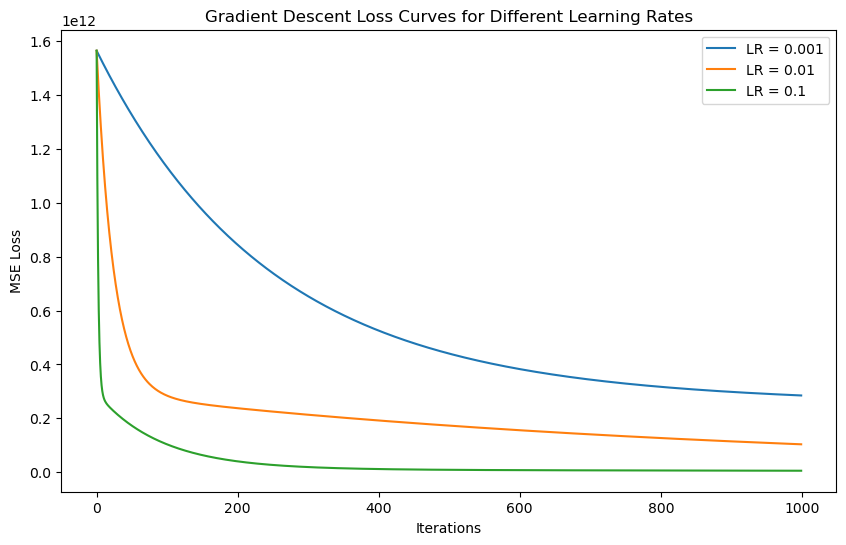

In [23]:
# YOUR CODE: gradient descent loop, loss curve, compare with normal equation

learning_rates = [0.001, 0.01, 0.1]
n_features = X_train_bias.shape[1] #columns
n_iterations = 1000
m = X_train_bias.shape[0] # rows size

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    # get random weights not correct, initialize zeros for the same size of feature columns
    # so i am getting weights for each correspondly for the start
    w = np.zeros(n_features)
    loss_history = []

    for i in range(n_iterations):
        # forwards & loss 
        y_hat = X_train_bias @ w
        error = y_hat - y_train

        #mse loss
        mse = np.mean(error**2)
        loss_history.append(mse)

        # computing the gradient
        gradient = (2/m) * (X_train_bias.T @ error)
        w = w - lr * gradient
        
    plt.plot(loss_history, label=f'LR = {lr}')

gd_weights = w

# 3. Print final weights and compare with Normal Equation weights
print("Final GD Weights (first 5):", gd_weights[:5])
print("Normal Eq Weights (first 5):", weights[:5])
print("Are weights close?", np.allclose(gd_weights, weights, atol=1e-1))

plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Loss Curves for Different Learning Rates')
plt.legend()
plt.show()

## 10. Evaluation on test set

Using your gradient descent weights:

1. Predict on the test set.
2. Compute RMSE, MAE, R² (your own functions).
3. **Baseline comparison:** What if the model just predicted the training mean for every row? Compute baseline RMSE and R². Your model must beat this.
4. **Verify with sklearn:** Fit `LinearRegression` on the same train data (without bias column — sklearn adds it). Check that `coef_` and `intercept_` match your weights (`np.allclose`).

**Question 10.** By how much does your model beat the baseline? Is R² good enough for real-world use, or would you need a better model?

In [31]:
# YOUR CODE: test predictions, metrics, baseline, sklearn comparison




from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# 1. Baseline metrics
baseline_pred = np.full_like(y_test, fill_value=y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

# 2. Scikit-learn Linear Regression (fit with X_train_scaled and y_train)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 3. Predictions
train_pred = lr.predict(X_train_scaled)
test_pred = lr.predict(X_test_scaled)

# 4. Evaluation metrics
train_r2 = r2_score(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

# 5. Results DataFrame
results_df = pd.DataFrame({
    'Model': ['Baseline (mean)', 'Linear Regression'],
    'Test MAE': [baseline_mae, test_mae],
    'Test MSE': [baseline_rmse**2, test_rmse**2],  # or RMSE if you prefer
    'Test R2': [baseline_r2, test_r2]
})

print(results_df.round(2))
print(f"\nTrain R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# 6. Verify coefficients match your Gradient Descent weights
print("Do sklearn coefs match GD weights?", np.allclose(lr.coef_, gd_weights[1:], atol=1e-1))
print("Do sklearn intercept match GD intercept?", np.allclose(lr.intercept_, gd_weights[0], atol=1e-1))

               Model   Test MAE      Test MSE  Test R2
0    Baseline (mean)  474832.68  2.851325e+11    -0.87
1  Linear Regression  434025.33  2.830891e+11    -0.86

Train R²: 1.0000
Test R²: -0.8589
Do sklearn coefs match GD weights? False
Do sklearn intercept match GD intercept? False


## 11. Residual analysis

Residuals = actual − predicted. A good model has residuals that look like random noise.

1. **Scatter plot:** predicted vs actual (should lie along the diagonal).
2. **Histogram** of residuals (should be roughly bell-shaped, centered at 0).
3. **Scatter plot:** predicted vs residuals (should show no pattern — just a horizontal cloud).
4. Print the 5 rows with the **largest absolute residuals**. Which stores/dates does the model struggle with most?

**Question 11.** Do the residuals look random, or is there a pattern? Are there outliers the model badly misses? What might cause those large errors?

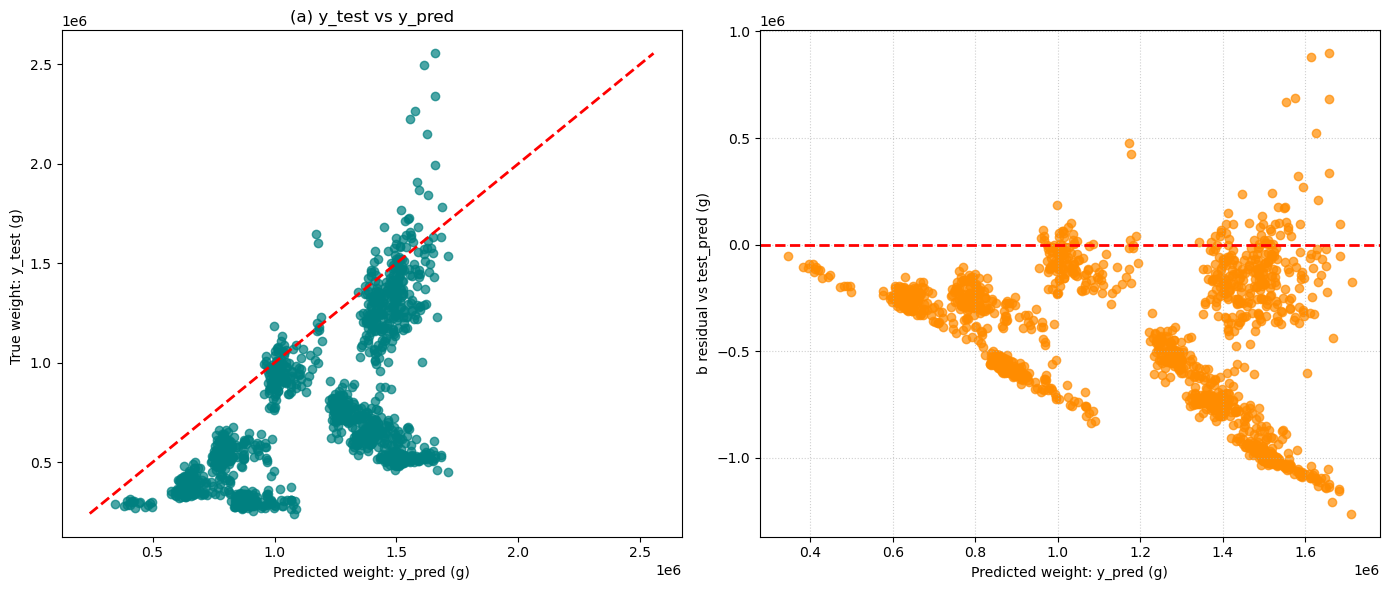

Top 5 worst errors (Index, Actual, Predicted, Residual):
Index 117: Actual = 451327.61, Pred = 1711929.80, Error = -1260602.19
Index 65: Actual = 460331.70, Pred = 1666354.74, Error = -1206023.04
Index 113: Actual = 527117.81, Pred = 1683296.06, Error = -1156178.25
Index 114: Actual = 537224.52, Pred = 1682255.52, Error = -1145031.00
Index 61: Actual = 508213.14, Pred = 1651067.47, Error = -1142854.33


In [46]:
# YOUR CODE: residual plots and analysis

residual = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(test_pred, y_test, alpha=0.7, color='teal')
min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Mukammal bashorat (y=x)')
axes[0].set_xlabel('Predicted weight: y_pred (g)')
axes[0].set_ylabel('True weight: y_test (g) ')
axes[0].set_title("(a) y_test vs y_pred")

axes[1].scatter(test_pred, residual, alpha=0.7, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted weight: y_pred (g)')
axes[1].set_ylabel('b residual vs test_pred (g)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

top5_idx = np.argsort(np.abs(residual))[::-1][:5]

print("Top 5 worst errors (Index, Actual, Predicted, Residual):")
for idx in top5_idx:
    print(f"Index {idx}: Actual = {y_test[idx]:.2f}, Pred = {test_pred[idx]:.2f}, Error = {residual[idx]:.2f}")

## 12. Feature importance

Since you scaled the features, the **magnitude of each weight** now reflects relative importance (unlike unscaled, where units differ).

1. Make a horizontal bar chart of the weights for the non-store features, sorted by absolute value.
2. Which features push sales **up** (positive weight)? Which push sales **down**?

**Question 12.** What are the top 3 most important features? Does this match your intuition from the EDA correlation analysis?

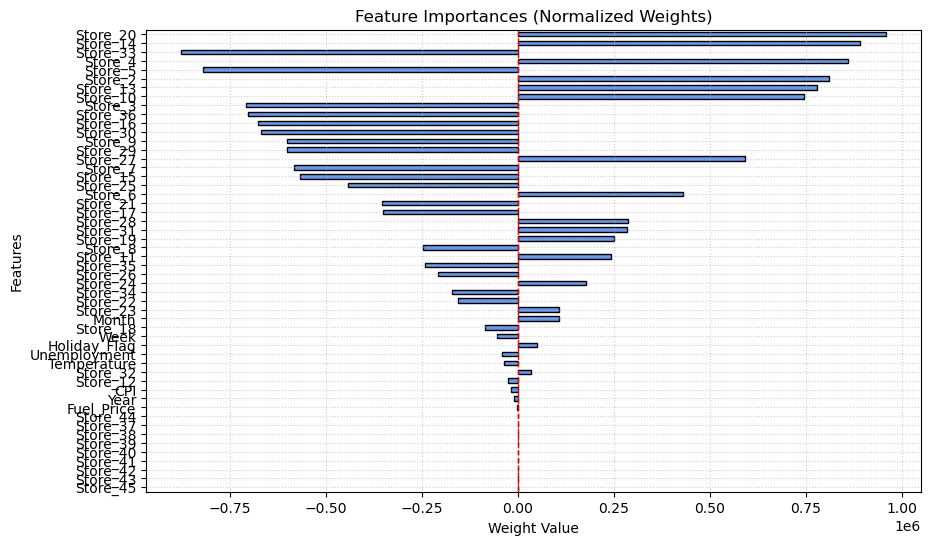

In [47]:
# YOUR CODE: bar chart of weights, sorted by |weight|
# 1. Identify non-store features (skip index 0 which is bias, and skip the one-hot store columns at the end)
# Assuming scale_cols are the continuous features and any other non-store columns exist before store dummies
non_store_feature_names = scale_cols  # or your list of continuous/non-store feature names
# Get the matching weights (skipping bias at index 0)
# We map gd_weights[1:] back to the feature names
feature_names = X_train_df.columns.tolist() if 'X_train_df' in locals() else scale_cols
weights_to_plot = gd_weights[1:len(feature_names)+1]

# Create a pandas Series for easy sorting by absolute value
feat_imp = pd.Series(weights_to_plot, index=feature_names)
feat_imp_sorted = feat_imp.reindex(feat_imp.abs().sort_values().index)

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 6))
feat_imp_sorted.plot(kind='barh', color='cornflowerblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', lw=1)
plt.title('Feature Importances (Normalized Weights)')
plt.xlabel('Weight Value')
plt.ylabel('Features')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 13. Improvements (pick at least 1)

Try one or more of these and report whether test R² improves:

1. **Log-transform the target:** `y = np.log1p(Weekly_Sales)`. Train on log-scale, then `np.expm1(y_pred)` to convert back. Recompute metrics on the original scale.
2. **Ridge regularization (L2):** Add `lambda * w` to the gradient (do not penalize the bias term). Try `lambda = 0.1, 1, 10`. Does test R² improve?
3. **Polynomial features:** Add `Temperature²` and `Month²` (or interaction terms like `Temperature × Holiday_Flag`). Does the model capture non-linear patterns?
4. **Per-store analysis:** Pick 3 stores and train a separate model for each. Do individual models beat the one combined model?

**Question 13.** Which improvement helped the most? Why?

In [ ]:
# YOUR CODE: at least 1 improvement

## ⭐ Bonus: MSE surface and contour

Pick the single most important feature (from section 12). Build a 2-parameter model: `y = θ₀ + θ₁ × feature`.

1. Create a 100×100 grid of (θ₀, θ₁) values around the optimal point.
2. Compute MSE at each grid point.
3. Plot the 3D surface (`plot_surface`) and the 2D contour (`contour`, `levels=30`).
4. Mark the Normal Equation solution as a red dot.

**Question (bonus).** Is the contour circular or an elongated ellipse? What determines the shape?

In [ ]:
# YOUR CODE: MSE surface and contour plot

## Conclusion

Write 5–10 sentences: What did you learn? Which result was unexpected? What would you do differently next time? What concept is still unclear?

In [ ]:
# YOUR CONCLUSION (write in a markdown cell below)

## Grading (100 + bonus)

| Criterion | Points |
|---|---|
| Sections 1–4: EDA complete, plots labeled | 20 |
| Sections 5–7: Feature engineering, split, scaling correct | 20 |
| Sections 8–9: Normal equation + GD implemented, loss curve plotted | 25 |
| Sections 10–11: Metrics computed, baseline beaten, residuals analyzed | 15 |
| Section 12: Feature importance chart | 5 |
| All Questions answered (13 total) with 2–5 sentences each | 10 |
| Code quality: functions, no errors on Run All, labeled plots | 5 |
| ⭐ Bonus: MSE surface | +10 |
| **Section 13: At least 1 improvement tried** | required |